In [1]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [2]:
df = pd.read_csv("../data/processed/hr_attrition_v2.csv")
df.head()

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,...,YearsWithCurrManager,income_log,tenure_ratio,promotion_gap_ratio,manager_tenure_ratio,distance_per_income,age_group,income_group,tenure_group,attrition_flag
0,41,Travel_Rarely,Sales,1,2,Life Sciences,2,Female,3,2,...,5,8.698514,0.666667,0.000000,0.714286,0.000167,36-45,중상,6-10년,1
1,49,Travel_Frequently,Research & Development,8,1,Life Sciences,3,Male,2,2,...,7,8.543056,0.909091,0.090909,0.636364,0.001559,46-55,중상,6-10년,0
2,37,Travel_Rarely,Research & Development,2,2,Other,4,Male,2,1,...,0,7.645398,0.000000,0.000000,0.000000,0.000956,36-45,저소득,0-2년,1
3,33,Travel_Frequently,Research & Development,3,4,Life Sciences,4,Female,3,1,...,0,7.975908,0.888889,0.333333,0.000000,0.001031,26-35,저소득,6-10년,0
4,27,Travel_Rarely,Research & Development,2,1,Medical,1,Male,3,1,...,2,8.151622,0.285714,0.666667,0.666667,0.000577,26-35,중하,0-2년,0


In [3]:
target_col = "attrition_flag"

X = df.drop(columns=[target_col]).copy()
y = df[target_col].astype(int).copy()

print(X.shape, y.shape)

(1470, 35) (1470,)


In [4]:
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print("숫자형 변수 수:", len(numeric_cols))
print("범주형 변수 수:", len(categorical_cols))
print(categorical_cols)

숫자형 변수 수: 25
범주형 변수 수: 10
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime', 'age_group', 'income_group', 'tenure_group']


In [5]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

final_logit_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]
)

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_prob = cross_val_predict(
    final_logit_model,
    X,
    y,
    cv=cv,
    method="predict_proba",
    n_jobs=None
)[:, 1]

print("OOF ROC-AUC:", roc_auc_score(y, oof_prob))
print("OOF PR-AUC:", average_precision_score(y, oof_prob))

OOF ROC-AUC: 0.8353677524886985
OOF PR-AUC: 0.5878072015394933


In [7]:
df_scored = df.copy()
df_scored["risk_score"] = oof_prob

df_scored[["risk_score", "attrition_flag"]].head()

,risk_score,attrition_flag
0,0.875684,1
1,0.080986,0
2,0.904880,1
3,0.585248,0
4,0.524019,0


In [8]:
q90 = df_scored["risk_score"].quantile(0.90)
q70 = df_scored["risk_score"].quantile(0.70)

def assign_risk_segment(x):
    if x >= q90:
        return "High Risk"
    elif x >= q70:
        return "Medium Risk"
    else:
        return "Low Risk"

df_scored["risk_segment"] = df_scored["risk_score"].apply(assign_risk_segment)

df_scored["risk_segment"].value_counts()

risk_segment
Low Risk       1029
Medium Risk     294
High Risk       147
Name: count, dtype: int64

In [9]:
segment_summary = (
    df_scored.groupby("risk_segment")["attrition_flag"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

segment_summary

,mean,count
risk_segment,,
High Risk,0.666667,147
Medium Risk,0.268707,294
Low Risk,0.058309,1029


In [10]:
# 핵심인재 proxy 생성 (JobLevel, PerformanceRating, MonthlyIncome 기준 2개이상 충족시 핵심인재로 임의 정의)
income_q75 = df_scored["MonthlyIncome"].quantile(0.75)

critical_score = (
    (df_scored["JobLevel"] >= 3).astype(int)
    + (df_scored["PerformanceRating"] >= 4).astype(int)
    + (df_scored["MonthlyIncome"] >= income_q75).astype(int)
)

df_scored["critical_talent_proxy"] = (critical_score >= 2).astype(int)

df_scored["critical_talent_proxy"].value_counts()

critical_talent_proxy
0    1123
1     347
Name: count, dtype: int64

In [11]:
# 개입 우선순위 정의 
def assign_intervention_priority(row):
    if row["risk_segment"] == "High Risk" and row["critical_talent_proxy"] == 1:
        return "즉시 유지 개입"
    elif row["risk_segment"] == "High Risk" and row["critical_talent_proxy"] == 0:
        return "선별 검토 대상"
    elif row["risk_segment"] == "Medium Risk" and row["critical_talent_proxy"] == 1:
        return "예방적 케어 대상"
    elif row["risk_segment"] == "Medium Risk" and row["critical_talent_proxy"] == 0:
        return "모니터링 대상"
    elif row["risk_segment"] == "Low Risk" and row["critical_talent_proxy"] == 1:
        return "핵심인재 일반 케어"
    else:
        return "일반 모니터링"

df_scored["intervention_priority"] = df_scored.apply(assign_intervention_priority, axis=1)

df_scored["intervention_priority"].value_counts()

intervention_priority
일반 모니터링       748
핵심인재 일반 케어    281
모니터링 대상       249
선별 검토 대상      126
예방적 케어 대상      45
즉시 유지 개입       21
Name: count, dtype: int64

In [12]:
# 우선순위별 현황표 
priority_summary = (
    df_scored.groupby("intervention_priority")["attrition_flag"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

priority_summary

,mean,count
intervention_priority,,
선별 검토 대상,0.698413,126
즉시 유지 개입,0.476190,21
모니터링 대상,0.285141,249
예방적 케어 대상,0.177778,45
핵심인재 일반 케어,0.064057,281
일반 모니터링,0.056150,748


In [13]:
priority_matrix = pd.crosstab(
    df_scored["risk_segment"],
    df_scored["critical_talent_proxy"],
    margins=True
)

priority_matrix

critical_talent_proxy,0,1,All
risk_segment,,,
High Risk,126,21,147
Low Risk,748,281,1029
Medium Risk,249,45,294
All,1123,347,1470


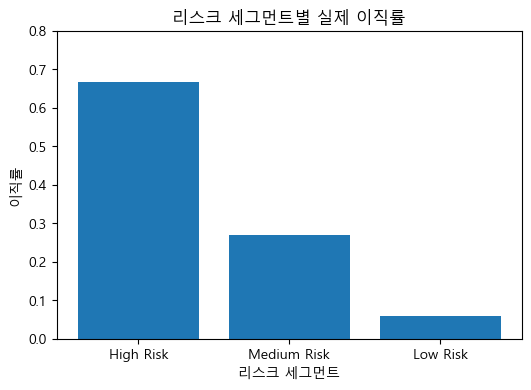

In [14]:
segment_plot = segment_summary.reset_index()

plt.figure(figsize=(6,4))
plt.bar(segment_plot["risk_segment"], segment_plot["mean"])
plt.title("리스크 세그먼트별 실제 이직률")
plt.xlabel("리스크 세그먼트")
plt.ylabel("이직률")
plt.ylim(0, segment_plot["mean"].max() * 1.2)
plt.show()

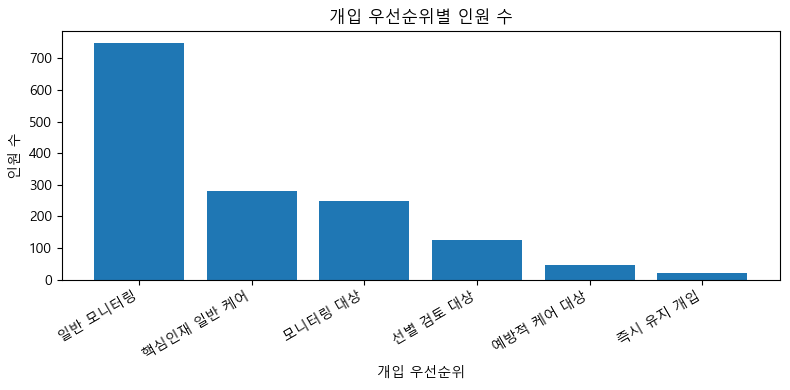

In [15]:
priority_count = df_scored["intervention_priority"].value_counts()

plt.figure(figsize=(8,4))
plt.bar(priority_count.index, priority_count.values)
plt.title("개입 우선순위별 인원 수")
plt.xlabel("개입 우선순위")
plt.ylabel("인원 수")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [16]:
df_scored.to_csv("../data/processed/hr_attrition_scored_v1.csv", index=False, encoding="utf-8-sig")
segment_summary.to_csv("../outputs/tables/risk_segment_summary.csv", encoding="utf-8-sig")
priority_summary.to_csv("../outputs/tables/intervention_priority_summary.csv", encoding="utf-8-sig")
priority_matrix.to_csv("../outputs/tables/intervention_priority_matrix.csv", encoding="utf-8-sig")

print("저장 완료")

저장 완료


리스크 세그먼트 및 개입 우선순위 설계 메모

- 최종 기준 모델은 로지스틱 회귀 사용
- 전 직원 risk score 산출 방식은 과적합 방지를 위해 OOF(out-of-fold) 예측확률 사용
- 리스크 세그먼트는 상위 10% High Risk, 상위 10~30% Medium Risk, 나머지 Low Risk로 정의
- 실제 핵심인재 여부 데이터 부재로 인해 JobLevel, PerformanceRating, MonthlyIncome 기준의 핵심인재 proxy 정의
- 개입 우선순위는 리스크 수준과 핵심인재 proxy를 결합해 정의
- 이 단계의 목적 : 예측 결과를 HR 개입 우선순위와 연결 가능한 의사결정 형태로 전환